# How To Categorize ML Problems

**Working Example.** Copy this file, rename it (replace _case with your alias), and modify your copy.

See docs/your-files.md for more information. 

Do not edit this example.
It should stay runnable and available as a reference
until after your work has been assessed. 

Your notebook should reflect your name (or alias), the date, your dataset, and your target in the opening below.

- Author: Matt Hanson
- Date: 2026-07
- Dataset: Seaborn Penguins
- Target: Species

Run all cells top to bottom (**Run All**) before pushing to GitHub.

## M1: ML Is Exploration

Analysts may use tools to help us load data, examine patterns, and
process components in machine-learning terms.

We frame the questions.  
We decide whether machine learning is a good tool,
which column might be able to be predicted (the target),
which features might help (the inputs),
and what the findings mean.

Choosing, analysis, and judgment come with the analyst.
Read data problems typically do not come with information
indicating whether it is supervised or unsupervised
or if we should use classification or regression.
We explore and find out.

## M1: ML Is Iterative

The first model tried is rarely the best.
When getting a new problem,
we try an approach, assess the results, modify things, reassess, and try again.
Several cycles are often needed before getting useful results.

## M1: Deciding How to Start and How to Improve a Model is Key

Learning to make these decisions is important.
We need to know how to explore and iterate to get actionable value out of data.
In all these exercises, think about how to find a good model.

After reading, you may delete this cell in your custom notebook.

## Overview

This project uses the penguins dataset.
We choose to predict the target `species`.
This target is a **category** variable (rather than numeric), so have a:

- supervised ML problem (because we've chosen a target)
- a classification problem (because our target is a category rather than numeric)

Customize the overview in your copy to reflect your dataset and choices.

## A. Prepare the Project Environment (.venv/)

- Open **only one project in VS Code at a time**.
- Prepare the .venv/: specify Python version and install / upgrade dependencies listed in `pyproject.toml`.
- Open an integrated terminal (PowerShell if Windows) in the **root project** folder and run:

```shell
uv self update
uv python pin 3.14
uv lock --upgrade
uv sync --extra dev --extra docs --upgrade
```

## B. Select the Notebook Kernel

- Click on the **Select Kernel** name in the top-right corner of the notebook interface.
- Choose Python Environments... /
- Choose the recommended local .venv/ from the drop-down menu.
- This will create a new kernel for the notebook and allow the notebook to use packages installed in the .venv/ environment.

## C. Working in Notebooks (Custom Notes)

- To run a cell, press **Ctrl+Enter** (or **Cmd+Enter** on Mac) when done editing the cell.
- Change the type of a cell (e.g., code or markdown) by looking in the lower left corner of the notebook interface.
- Rearrange cells by dragging and dropping them within the notebook.

See [Run Jupyter Notebooks](https://denisecase.github.io/pro-analytics-02/workflow-b-apply-example-project/run-notebook/) for:

- how to **copy a notebook**
- how to release a `project.log` file
- how to deal with a **stuck kernel**
- etc.

## Section 0. Introduction to Machine Learning

**Machine learning (ML)** is building a model from data so
the model can make useful predictions or decisions about new data.
ML is an alternative to us writing logic explicitly,
it means the machine "learns" from the data (using statistics).

We use ML for:

- **Classification**, to sort items into categories (e.g., spam vs. not, fraud vs. not, which species).
- **Regression**, to predict a number (e.g.,price, mass, temperature, demand).
- **Recommendation**, to suggest the next item (e.g.,what to watch, read, buy).
- **Detection / ranking**, to surface the unusual or the most relevant (ae.g.,nomalies, search results).
- **Forecasting**, to project a value in the future.

ML is not always a good choice.
If a simple rule, a lookup, or a direct calculation answers a question, use that.
ML is useful when a pattern is real,
there is enough representative data,
and the rules or relationships are too complex or unknown to encode by hand.
The analyst knows when a problem could benefit from ML.

### Core Vocabulary

| Term                  | Meaning                                                 | Also called             |
| --------------------- | ------------------------------------------------------- | ----------------------- |
| instance              | one row / one observation                               | sample, example, record |
| feature, **X**        | one input column used to predict                        | predictor, attribute    |
| target, **y**         | the column we want to predict                           | label, response         |
| supervised learning   | learning from data that includes the target             | -                       |
| unsupervised learning | finding structure with **no** target (e.g., clustering) | -                       |
| classification        | use when target is a **category**                       | -                       |
| regression            | use when target is a **number**                         | -                       |
| model                 | the thing fit to data that makes predictions            | estimator               |
| training / fitting    | adjusting the model to the data                         | learning                |
| prediction            | the model's output for an instance                      | inference               |

Project Learning Objective:

- Given any dataset, be able to say
- what the **instances** are,
- which columns could be **features**,
- which could be a **target**, and therefore
- whether a question is **supervised or unsupervised** and
- whether it benefits from **classification or regression**.


## Section 1. Project Setup and Imports

All imports and configuration appear once, at the top of the notebook.
Bring in the libraries, configure a logger,
set a few constants you may customize, and
confirm the packages are installed by logging their versions.

WHY:

- Keeps notebooks readable and reproducible
- Mirrors professional scripts
- Verifies prerequisites


In [6]:
# === Section 1a. DECLARE IMPORTS (BRING IN FREE CODE) ===

from importlib.metadata import version  # to verify
import logging  # for type hinting
import platform  # to verify
from typing import Final  # for type hinting

from datafun_toolkit.logger import get_logger, log_header
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# === Section 1b. CONFIGURE LOGGER ONCE PER NOTEBOOK ===

LOG: logging.Logger = get_logger("M01", level="DEBUG")
log_header(LOG, "M01")

# === Section 1c. USE THE LOGGER TO VERIFY IMPORTS ===

# If any do NOT return a version number, then that package is not installed correctly.
# Check your pyproject.toml and re-run environment setup commands.

LOG.info("Confirming installation:")
LOG.info(f"  python:       {platform.python_version()}")
LOG.info(f"  pandas:       {version('pandas')}")
LOG.info(f"  numpy:        {version('numpy')}")
LOG.info(f"  scikit-learn: {version('scikit-learn')}")
LOG.info(f"  seaborn:      {version('seaborn')}")
LOG.info(f"  matplotlib:   {version('matplotlib')}")

sns_dataset_list = sns.get_dataset_names()  # shows all built-in datasets
LOG.info(f"Built-in Seaborn datasets: {sns_dataset_list}")

# === Section 1d. SET PANDAS DISPLAY CONFIGURATION (helps in notebooks) ===

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 120)

2026-07-05 21:15:15 | INFO | M01 | === RUN START ===
2026-07-05 21:15:15 | INFO | M01 | project=M01
2026-07-05 21:15:15 | INFO | M01 | repo_dir=ml-01-intro-hanson
2026-07-05 21:15:15 | INFO | M01 | python=3.14.3
2026-07-05 21:15:15 | INFO | M01 | os=Windows 11
2026-07-05 21:15:15 | INFO | M01 | shell=powershell
2026-07-05 21:15:15 | INFO | M01 | cwd=notebooks
2026-07-05 21:15:15 | INFO | M01 | github_actions=False
2026-07-05 21:15:15 | INFO | M01 | Confirming installation:
2026-07-05 21:15:15 | INFO | M01 |   python:       3.14.3
2026-07-05 21:15:15 | INFO | M01 |   pandas:       3.0.3
2026-07-05 21:15:15 | INFO | M01 |   numpy:        2.5.1
2026-07-05 21:15:15 | INFO | M01 |   scikit-learn: 1.9.0
2026-07-05 21:15:15 | INFO | M01 |   seaborn:      0.13.2
2026-07-05 21:15:15 | INFO | M01 |   matplotlib:   3.11.0
2026-07-05 21:15:15 | INFO | M01 | Built-in Seaborn datasets: ['anagrams', 'anscombe', 'attention', 'brain_networks', 'car_crashes', 'diamonds', 'dots', 'dowjones', 'exercise', 

## Section 2. Load the Data


In [7]:
# === Section 2. Load the Data ===

# We are loading data from Seaborn's built-in datasets,
# which are small datasets included with the Seaborn library
# for practice and demonstration purposes.
# They are listed above with sns.get_dataset_names().
# Experiment with different ones to see what they contain.
# You can also load from CSV files, databases, or APIs and process is similar.

# CUSTOM: In this example, I load a Seaborn dataset by name (no external CSV).
# Change to explore a different dataset.
DATASET_NAME: Final[str] = "penguins"

LOG.info(f"Loading dataset: {DATASET_NAME}")
df: pd.DataFrame = sns.load_dataset(DATASET_NAME)
LOG.info(f"Loaded: {df.shape[0]} rows (instances), {df.shape[1]} columns")

2026-07-05 21:17:55 | INFO | M01 | Loading dataset: penguins
2026-07-05 21:17:55 | INFO | M01 | Loaded: 344 rows (instances), 7 columns


## Section 3. Inspect and Characterize the Data

Important:

- Name the parts of a dataset using ML vocabulary.
- Describe the dataset using machine-learning vocabulary.

WHY: All ML starts here.
First, name the instances, the numeric features, and the categorical columns.
Then, decide what kind of ML question the data can answer.

- Each ROW is one INSTANCE.
- Each COLUMN is a candidate FEATURE or TARGET.
- NUMERIC columns can be a regression target or a numeric feature.
- CATEGORICAL columns can be a classification target or a category feature.


2026-07-05 21:20:06 | INFO | M01 | Instances (rows): 344
2026-07-05 21:20:06 | INFO | M01 | Columns:          7
2026-07-05 21:20:06 | INFO | M01 | Numeric columns (regression target / numeric feature): ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']
2026-07-05 21:20:06 | INFO | M01 | Categorical columns (classification target / category): ['species', 'island', 'sex']
2026-07-05 21:20:06 | INFO | M01 | Missing values by column:
species               0
island                0
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11
dtype: int64
2026-07-05 21:20:06 | INFO | M01 | Missing values across all columns: 19
2026-07-05 21:20:06 | DEBUG | M01 | First rows:
2026-07-05 21:20:06 | DEBUG | M01 | 
  species     island  bill_length_mm  bill_depth_mm  flipper_length_mm  body_mass_g     sex
0  Adelie  Torgersen            39.1           18.7              181.0       3750.0    Male
1  Adelie  Torgersen  

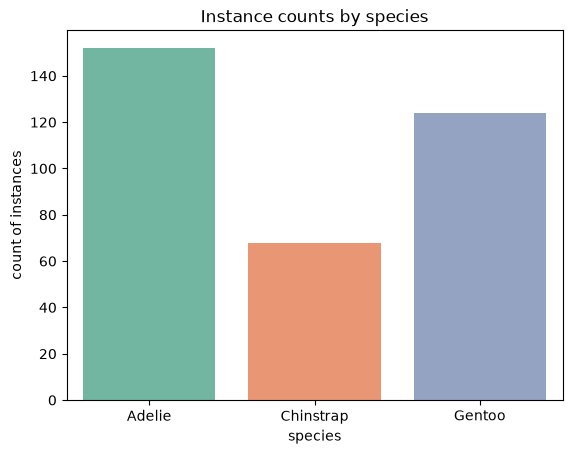

In [8]:
# === Section 3. Inspect and Characterize the Data in ML Terms ===

row_count, col_count = df.shape

LOG.info(f"Instances (rows): {row_count}")  # or df.shape[0]
LOG.info(f"Columns:          {col_count}")  # or df.shape[1] or len(df.columns)

numeric_cols_list: list[str] = df.select_dtypes(include="number").columns.tolist()
category_cols_list: list[str] = df.select_dtypes(exclude="number").columns.tolist()

LOG.info(f"Numeric columns (regression target / numeric feature): {numeric_cols_list}")
LOG.info(
    f"Categorical columns (classification target / category): {category_cols_list}"
)

missing: pd.Series = df.isna().sum()
LOG.info(f"Missing values by column:\n{missing}")

missing_total: int = int(missing.sum())
LOG.info(f"Missing values across all columns: {missing_total}")

LOG.debug("First rows:")
LOG.debug(f"\n{df.head()}")

# A first picture.
# Visualize something in every project.
# If the column is a category, a countplot is a good first look at the distribution of instances across categories.

# If the category_cols_list is not empty, then make a plot of the first categorical column.
if category_cols_list:
    # start a new figure
    plt.figure()

    # get the name of the  first categorical column (index is 0)
    plot_col_name: str = category_cols_list[0]

    # countplot shows the count of instances in each category for the specified column
    sns.countplot(
        data=df, x=plot_col_name, hue=plot_col_name, palette="Set2", legend=False
    )

    # Set the title and axis labels for the plot
    plt.title(f"Instance counts by {plot_col_name}")
    plt.xlabel(plot_col_name)
    plt.ylabel("count of instances")

    # Show the plot
    plt.show()

## Section 4. Frame an ML Question

A column becomes a "target" when we decide to try to predict it.

Picking the target fixes the kind of ML problem:

- if target is a NUMBER, then regression
- if target is a CATEGORY, then classification
- no target selected, then unsupervised (e.g., clustering) - we're exploring

Report the KIND of ML problem implied by the chosen target, `CANDIDATE_TARGET`.

WHY: A dataset supports many questions. 
Choosing the target is an analyst decision; 
once chosen, whether it is numeric or categorical
determines whether the task is regression or classification, 
and the remaining columns become the candidate features (inputs).

NOTE: This does NOT decide whether the question is worth asking or
even whether ML is the right tool.


In [4]:
# === Section 4. Frame an ML Question ===

# 4.1 CHOOSE A TARGET COLUMN --------------

# Look at the dataset and pick a column to predict.
# This is the "target" variable, the thing we want to predict with machine learning.
# Do not choose an ID column or a column with unique values for each row, as those cannot be predicted.
CANDIDATE_TARGET: Final[str] = "species"

# Check to ensure our target is in the dataset
if CANDIDATE_TARGET not in df.columns:
    LOG.warning(f"CANDIDATE_TARGET '{CANDIDATE_TARGET}' is not a column.")
    LOG.warning(f"Available columns: {df.columns.tolist()}")

LOG.info(f"Chosen target (y): {CANDIDATE_TARGET}")

# The target variable is often denoted as "y" in ML,
# and the features (the columns we will use to predict the target)
# are often denoted as "X".

# 4.2 IS THE TARGET NUMERIC OR CATEGORICAL? -----------

# use pandas API to check if the target column is numeric or not
# this determines the type of ML problem.

# We calculate it just for instructional purposes.
# Most analysts can determine this and just document it in the framing.
target_is_numeric: bool = pd.api.types.is_numeric_dtype(df[CANDIDATE_TARGET])
LOG.info(f"Target is numeric? {target_is_numeric}")

# 4.3 DETERMINE THE TYPE OF ML PROBLEM -----------

# the type is either regression (if the target is numeric) or
# classification (if the target is categorical).
problem_type: str = (
    "regression (we want to predict a number)"
    if target_is_numeric
    else "classification (we want to predict a category)"
)
LOG.info(f"Implied problem type: {problem_type}")

# 4.4 LIST CANDIDATE FEATURES -----------

# Candidate features are all columns EXCEPT the target.
# In Module 1 we just focus on framing a problem.
# We do not build a model yet,
# so we don't worry about feature selection or engineering yet.
feature_list: list[str] = [c for c in df.columns if c != CANDIDATE_TARGET]  # pyright: ignore[reportUnusedVariable]
LOG.info(f"Candidate features (X): {feature_list}")

2026-07-05 20:32:33 | INFO | M01 | Chosen target (y): species
2026-07-05 20:32:33 | INFO | M01 | Target is numeric? False
2026-07-05 20:32:33 | INFO | M01 | Implied problem type: classification (we want to predict a category)
2026-07-05 20:32:33 | INFO | M01 | Candidate features (X): ['island', 'bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g', 'sex']


## Section 5. Summary and Next Steps

First, output key information (may use Python)
Second, provide your narrative, conclusions, and next steps (in Markdown)

In [5]:
# === Python Summary ===

LOG.info("========================")
LOG.info("SUMMARY OF KEY FACTS")
LOG.info("========================")
LOG.info(f"Dataset:           {DATASET_NAME}")
LOG.info(f"Instances:         {df.shape[0]}")
LOG.info(f"Candidate target:  {CANDIDATE_TARGET}")
LOG.info(f"Problem type:      {problem_type}")
LOG.info(f"Candidate features: {feature_list}")
LOG.info("========================")

2026-07-05 20:32:35 | INFO | M01 | ========================
2026-07-05 20:32:35 | INFO | M01 | SUMMARY OF KEY FACTS
2026-07-05 20:32:35 | INFO | M01 | ========================
2026-07-05 20:32:35 | INFO | M01 | Dataset:           penguins
2026-07-05 20:32:35 | INFO | M01 | Instances:         344
2026-07-05 20:32:35 | INFO | M01 | Candidate target:  species
2026-07-05 20:32:35 | INFO | M01 | Problem type:      classification (we want to predict a category)
2026-07-05 20:32:35 | INFO | M01 | Candidate features: ['island', 'bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g', 'sex']
2026-07-05 20:32:35 | INFO | M01 | ========================



### Custom Narrative

Summarize your work in this Markdown cell in your notebook.

### Custom Conclusions

UPDATE THESE REMARKS IN YOUR COPY: 

This is SUPERVISED learning (because the data includes a target).

The chosen target is `species` and that is a category column. 

Therefore, modeling this problem will use classification.

### Next Steps

Summarize your next steps in this Markdown cell in your notebook.


## Task: Make the Notebook Yours (Apply / Extend / Explore)

This is an example.
Copy this notebook and make it your own. 

In your copy:

1. At the beginning, update the Author, the purpose, the target, etc. 
2. Remove any instructions you do not need. 

Try things like the following.

1. **Apply** - Change `DATASET_NAME` to another Seaborn dataset
   (e.g., `"tips"`, `"diamonds"`, `"titanic"`) or load your own CSV into
   `data/raw/`. Re-run and check the characterization against the vocabulary.
2. **Extend** - Change `CANDIDATE_TARGET` to a numeric column and 
   then a categorical one. 
   Confirm the implied problem type flips between regression
   and classification, and explain why in a Markdown cell.
3. **Explore** - Pick a dataset where you are unsure 
   whether ML is the right tool. 
   Argue both sides in `docs/index.md`.
   There is no single correct answer; 
   the reasoning is the work / value.


## Task: Finalize Your README.md

Include in README.md:

- your project description
- any instructions
- your commands
- a link to key artifacts (including your executed notebook)

When done, you may delete this instruction in your custom notebook.


## Task: Finalize your docs/index.md

In your docs/index.md, include things like:

- Your target.
- Why predicting this target could be useful and for whom.
- Whether ML is a good tool for this problem and why or why not. 
- For example, would a simple rule work better?
- Which features look informative, and which look irrelevant.
- What might 'good enough' mean for this question.

Important:

- There is no threshold that answers these questions automatically.
- Use notebook, README.md, and docs/index.md to share your judgement and your ML skills.


## Task: Final Check

- `README.md` - reflects your description, instructions, commands, and links to your executed notebook.
- `docs/index.md` - reflects your project-specific updates.
- Your GitHub **About** section has a link to your hosted documentation site.
- The executed example notebook AND your custom notebook are available in `notebooks/`.
- Keep this **working example** alongside your custom work until your work has been assessed.
- Ensure your **custom notebook** introduces and narrates **your** custom project.

## Reminder: Run All before pushing to GitHub

Before saving a notebook (and running git add-commit-push), click 'Run All' to generate all outputs and display them in the notebook.

Follow our [pro-analytics-02](https://denisecase.github.io/pro-analytics-02/) common workflows.

Your README.md should have a description, a link to your executed notebook, and a list of commands (updated as you add your custom description, instructions, and commands).

Your docs/ folder should document your custom project analysis in the `docs/index.md` summary.
